In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/feature_engineered_data.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,temp_gap,power,wear_rate,heat_stress,stress_index
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40,0.0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15,138.9
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76,247.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80,276.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0,0.008728,283.20,413.0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6,0.010417,302.10,540.6
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0,0.013374,320.64,734.8
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0,0.017756,470.45,1212.5


In [2]:
df.shape

(10000, 19)

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,temp_gap,power,wear_rate,heat_stress,stress_index
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40,0.0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15,138.9
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76,247.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80,276.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00,360.0


In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'Tool Wear Failure',
       'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure',
       'Random Failure', 'temp_gap', 'power', 'wear_rate', 'heat_stress',
       'stress_index'],
      dtype='object')

# **Avoiding Data Leakage**

In [5]:
df_model = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Tool Wear Failure",
        "Heat Dissipation Failure",
        "Power Failure",
        "Overstrain Failure",
        "Random Failure"
    ]
)

In [6]:
df_model.shape

(10000, 12)

In [7]:
df_model.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_gap,power,wear_rate,heat_stress,stress_index
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.000000,449.40,0.0
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.002131,486.15,138.9
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.003338,513.76,247.0
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.004885,410.80,276.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.006392,420.00,360.0


# **One Hot Encoding**

In [8]:
df_model = pd.get_dummies(
    df_model,
    columns=["Type"],
    drop_first=True
)

In [9]:
df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_gap,power,wear_rate,heat_stress,stress_index,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.000000,449.40,0.0,False,True
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0.002131,486.15,138.9,True,False
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0.003338,513.76,247.0,True,False
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0.004885,410.80,276.5,True,False
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0.006392,420.00,360.0,True,False


In [10]:
df_model.shape

(10000, 13)

# **Split Target column**

In [11]:
X = df_model.drop(
  columns=["Machine failure"]
)

y= df_model["Machine failure"]

In [12]:
print(X.shape)
print(y.shape)

(10000, 12)
(10000,)


# **Train test Split**

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 12)
(2000, 12)
(8000,)
(2000,)


In [15]:
y_train.value_counts()

,count
Machine failure,
0,7729
1,271


In [16]:
y_test.value_counts()

,count
Machine failure,
0,1932
1,68


# **BaseLine Model -> Logistic Regression**

In [20]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)


accuracy = accuracy_score(
    y_test,
    y_pred_lr
)
print(f"\nAccuracy: {accuracy:.4f}")

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)


Accuracy: 0.9690
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1932
           1       0.62      0.24      0.34        68

    accuracy                           0.97      2000
   macro avg       0.79      0.62      0.66      2000
weighted avg       0.96      0.97      0.96      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Summary

The Logistic Regression model achieved **96.9% accuracy**, but accuracy is misleading due to the imbalanced dataset.

The model achieved only **24% recall** for the failure class, detecting just **16 out of 68** actual failures while missing **52 failures**.

Although the model performs well on healthy machines, it struggles to identify machine failures. Therefore, Logistic Regression serves as a baseline model but is not suitable for real-world predictive maintenance applications.


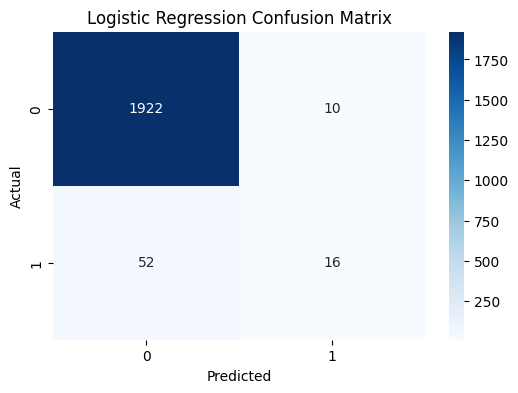

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Desicion Tree**

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)



accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print(f"\nAccuracy: {accuracy:.4f}")

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)



confusion_matrix(
    y_test,
    y_pred_dt
)


Accuracy: 0.9845
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.79      0.78        68

    accuracy                           0.98      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.98      0.98      0.98      2000



array([[1915,   17],
       [  14,   54]])

# **Random Forest**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(f"\nAccuracy: {accuracy:.4f}")


print(
    classification_report(
        y_test,
        y_pred_rf
    )
)



confusion_matrix(
    y_test,
    y_pred_rf
)




Accuracy: 0.9930
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.97      0.82      0.89        68

    accuracy                           0.99      2000
   macro avg       0.98      0.91      0.94      2000
weighted avg       0.99      0.99      0.99      2000



array([[1930,    2],
       [  12,   56]])

Three machine learning models were evaluated for machine failure prediction: Logistic Regression, Decision Tree, and Random Forest. Among them, Random Forest achieved the best performance with 99.3% accuracy, 97% precision, 82% recall, and 89% F1-score on the failure class. Therefore, Random Forest was selected as the final predictive model for this project.

# **Cross Validation**

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=skf,
    scoring="f1"
)

print(cv_scores)
print("Average F1:", cv_scores.mean())

[0.88709677 0.91472868 0.88       0.87096774 0.87804878]
Average F1: 0.886168395757476


# **Cross Validation Results**

To evaluate the stability and generalization capability of the Random Forest model, 5-fold Stratified Cross Validation was performed.

The obtained F1-scores were:

0.887, 0.915, 0.880, 0.871, and 0.878

The average F1-score was 0.886.

The low variation among folds indicates that the model is stable and generalizes well across different subsets of the dataset.

# **Hyperparameter tunning**

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
0.8721359940872135


# Evaluate Random Forest

In [31]:
# ==========================
# Evaluate Tuned Random Forest
# ==========================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best Model from GridSearch
best_rf = grid.best_estimator_

# Prediction
y_pred_best = best_rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("Accuracy:", round(accuracy, 4))

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9915

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.78      0.86        68

    accuracy                           0.99      2000
   macro avg       0.98      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1930    2]
 [  15   53]]


### Final Model Selection

Three machine learning algorithms were evaluated for machine failure prediction: Logistic Regression, Decision Tree, and Random Forest.

The Random Forest model achieved the best performance with an accuracy of 99.3%, precision of 97%, recall of 82%, and F1-score of 89% on the failure class.

Hyperparameter tuning was also performed using GridSearchCV. However, the tuned model did not outperform the default Random Forest model. Therefore, the default Random Forest classifier was selected as the final model.

A 5-fold Stratified Cross Validation was conducted, resulting in an average F1-score of 0.886, indicating strong stability and generalization capability.

The final model successfully identified 56 out of 68 machine failures while maintaining a very low false positive rate.


In [33]:
# Final model
import joblib

joblib.dump(
    rf,
    "machine_failure_model.pkl"
)

['machine_failure_model.pkl']

XGBOOST RESULTS

Accuracy: 0.9915

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.81      0.87        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:

[[1928    4]
 [  13   55]]


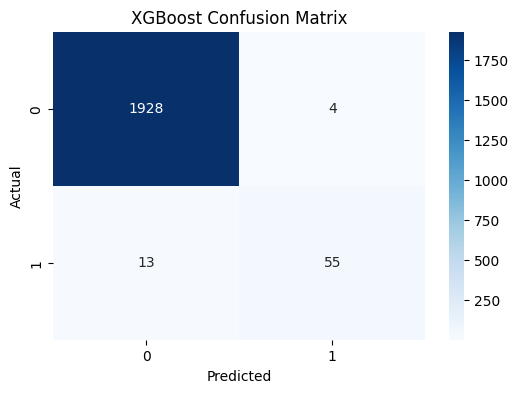


Cross Validation F1 Scores:
[0.84848485 0.85714286 0.81481481 0.89108911 0.8490566 ]

Average F1: 0.8521176466253992

Top Features:

                   Feature  Importance
2    Rotational_speed_rpm_    0.223298
9             stress_index    0.186085
6                    power    0.175893
5                 temp_gap    0.103823
4           Tool_wear_min_    0.079083
3               Torque_Nm_    0.068930
10                  Type_L    0.051593
11                  Type_M    0.030284
7                wear_rate    0.027676
0       Air_temperature_K_    0.022731
8              heat_stress    0.016062
1   Process_temperature_K_    0.014542


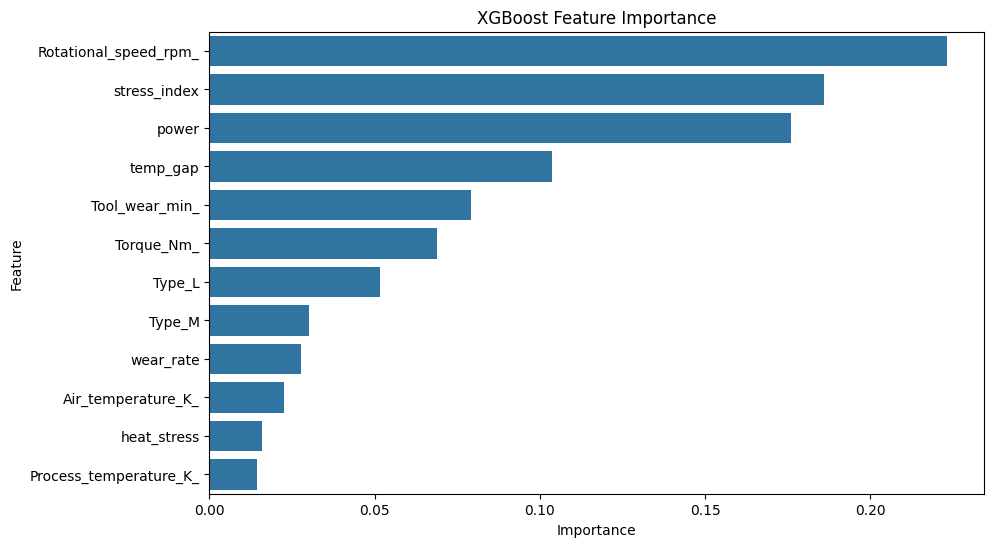

In [35]:
# =====================================
# Notebook 8 : XGBoost Classifier
# =====================================

# Install XGBoost (Run once in Colab)
!pip install xgboost -q

# =====================================
# Import Libraries
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import cross_val_score

# =====================================
# Clean feature names for XGBoost
# =====================================
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# =====================================
# Train XGBoost Model
# =====================================

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

# =====================================
# Prediction
# =====================================

y_pred_xgb = xgb.predict(
    X_test
)

# =====================================
# Accuracy
# =====================================

accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print(f"\nAccuracy: {accuracy:.4f}")

# =====================================
# Classification Report
# =====================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\nConfusion Matrix:\n")
print(cm)

# =====================================
# Confusion Matrix Heatmap
# =====================================

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =====================================
# Cross Validation
# =====================================

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\nCross Validation F1 Scores:")
print(cv_scores)

print(
    "\nAverage F1:",
    cv_scores.mean()
)

# =====================================
# Feature Importance
# =====================================

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:\n")

print(
    importance_df.head(15)
)

# =====================================
# Feature Importance Plot
# =====================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()
